In [1]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import pandas as pd
import shapely

In [ ]:
def hillshade(array: np.ndarray, azimuth: int = 315, angle_altitude: int = 45):
    """
    Computes hillshade from a 2D array of elevation data.
    Calculates the gradient to determine slope and aspect,
    then computes hillshade based on specified azimuth and altitude angles.
    - Azimuth is the direction of the light source in degrees (0° is north, 90° is east, 180° is south, 270° is west).
    - Altitude is the angle of the light source above the horizon in degrees.

    Args:
        array (np.ndarray): 2D array of elevation data.
        azimuth (int, optional): Azimuth angle in degrees. Defaults to 315.
        angle_altitude (int, optional): Altitude angle in degrees. Defaults to 45.

    Returns:
        np.ndarray: Hillshade image as a 2D array with values scaled from 0 to 255.
    """
    x, y = np.gradient(array)
    slope = np.pi / 2.0 - np.arctan(np.sqrt(x * x + y * y))
    aspect = np.arctan2(-x, y)
    azimuth_rad = azimuth * np.pi / 180.0
    altitude_rad = angle_altitude * np.pi / 180.0
    shaded = np.sin(altitude_rad) * np.sin(slope) + np.cos(altitude_rad) * np.cos(
        slope
    ) * np.cos(azimuth_rad - aspect)
    return 255 * (shaded + 1) / 2

Dataset profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -9999.0, 'width': 5000, 'height': 5000, 'count': 1, 'crs': CRS.from_wkt('PROJCS["Estonian Coordinate System of 1997",GEOGCS["EST97",DATUM["Estonia_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6180"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4180"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",57.5175539305556],PARAMETER["central_meridian",24],PARAMETER["standard_parallel_1",59.3333333333333],PARAMETER["standard_parallel_2",58],PARAMETER["false_easting",500000],PARAMETER["false_northing",6375000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","3301"]]'), 'transform': Affine(1.0, 0.0, 490000.0,
       0.0, -1.0, 6510000.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 

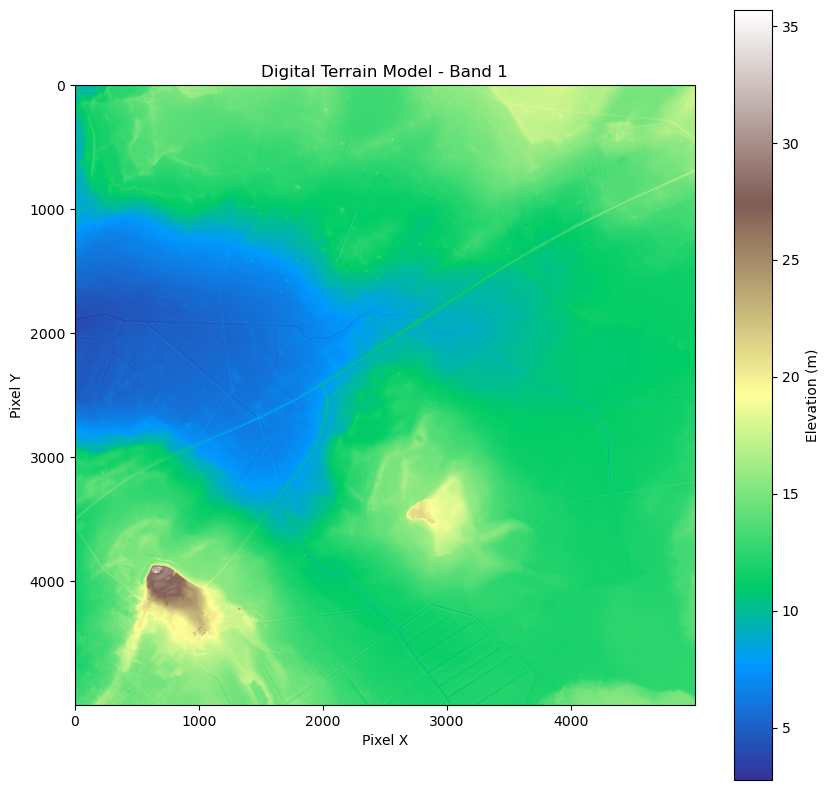

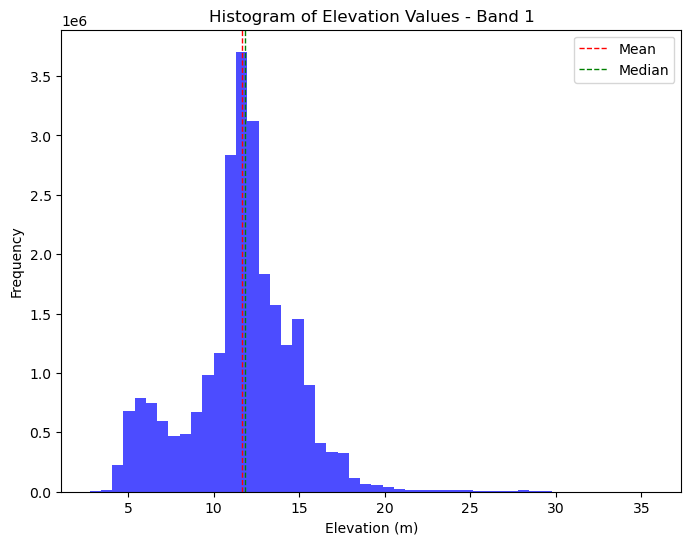

Basic Statistics for Band 1:
Min value: 2.76
Max value: 35.69
Mean value: 11.69
Standard Deviation: 3.18
Median value: 11.87
25th percentile: 10.37
75th percentile: 13.48

Count of valid data points: 25000000


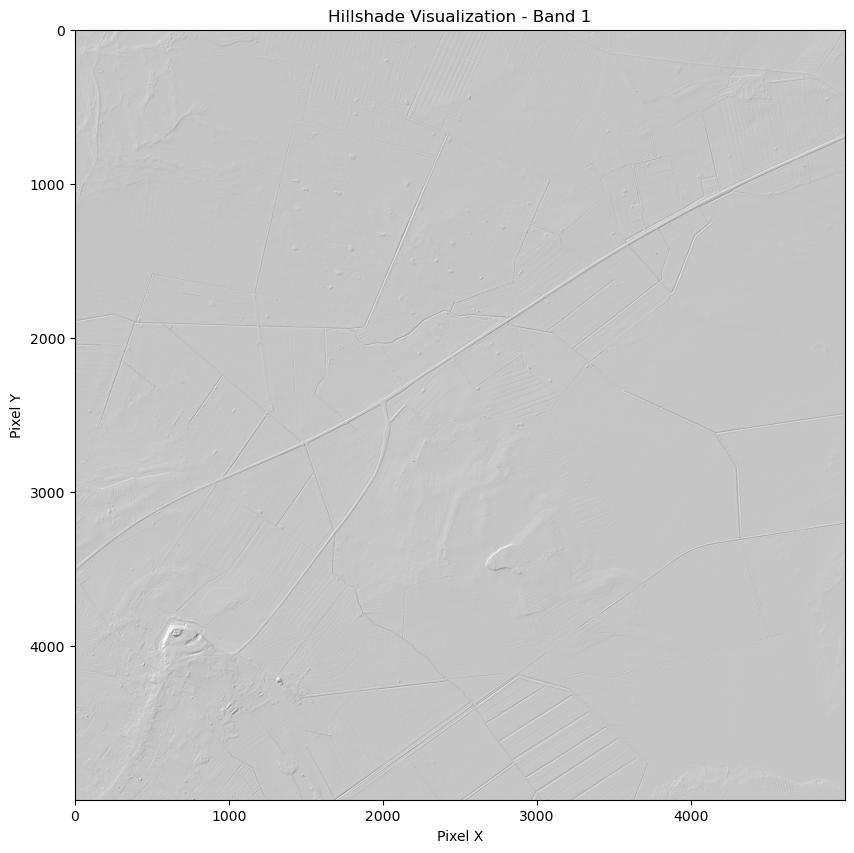

In [ ]:
# Inspecting a Digital Terrain Model's tif file
with rasterio.open("../data/raw/dtm/62093_dtm_1m.tif") as dataset:
    # Print dataset profile
    print(f"Dataset profile: {dataset.profile}")
    # Print width and height
    print(f"Width: {dataset.width}, Height: {dataset.height}")
    # Print coordinate reference system
    print(f"CRS: {dataset.crs}")
    # Print transform information. This includes pixel size and origin.
    print(f"Transform: {dataset.transform}")
    # Print bounds of the dataset
    print(f"Bounds: {dataset.bounds}")
    # Print number of bands
    print(f"Number of bands: {dataset.count}")
    # Print data types of the bands
    print(f"Data types: {dataset.dtypes}")
    # Print driver information
    print(f"Driver: {dataset.driver}")
    # Print no data value
    print(f"No data value: {dataset.nodata}")
    # Print metadata
    print(f"Metadata: {dataset.meta}")

    # Plot the first band
    band1 = dataset.read(1)

    # Visualize the first band
    plt.figure(figsize=(10, 10))
    plt.imshow(band1, cmap="terrain")
    plt.colorbar(label="Elevation (m)")
    plt.title("Digital Terrain Model - Band 1")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.show()

    # Plot value histogram for the first band
    plt.figure(figsize=(8, 6))
    plt.hist(band1.flatten(), bins=50, color="blue", alpha=0.7)
    # Add vertical lines for mean and median
    plt.axvline(
        band1.mean(), color="red", linestyle="dashed", linewidth=1, label="Mean"
    )
    plt.axvline(
        np.median(band1), color="green", linestyle="dashed", linewidth=1, label="Median"
    )
    plt.title("Histogram of Elevation Values - Band 1")
    plt.xlabel("Elevation (m)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    # Compute and print basic statistics for the first band
    print("Basic Statistics for Band 1:")
    print(f"Min value: {band1.min():.2f}")
    print(f"Max value: {band1.max():.2f}")
    print(f"Mean value: {band1.mean():.2f}")
    print(f"Standard Deviation: {band1.std():.2f}")
    print(f"Median value: {np.median(band1):.2f}")
    print(f"25th percentile: {np.percentile(band1, 25):.2f}")
    print(f"75th percentile: {np.percentile(band1, 75):.2f}")
    print()

    # Create a mask for no data values and print the count of valid data points
    no_data_mask = band1 == dataset.nodata
    valid_data_count = np.sum(~no_data_mask)
    print(f"Count of valid data points: {valid_data_count}")

    # Create a simple hillshade visualization
    hillshade_image = hillshade(band1)
    plt.figure(figsize=(10, 10))
    plt.imshow(hillshade_image, cmap="gray")
    plt.title("Hillshade Visualization - Band 1")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.show()

Dataset profile: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 25000, 'height': 25000, 'count': 3, 'crs': CRS.from_wkt('PROJCS["Estonian Coordinate System of 1997",GEOGCS["EST97",DATUM["Estonia_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6180"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4180"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",57.5175539305556],PARAMETER["central_meridian",24],PARAMETER["standard_parallel_1",59.3333333333333],PARAMETER["standard_parallel_2",58],PARAMETER["false_easting",500000],PARAMETER["false_northing",6375000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","3301"]]'), 'transform': Affine(0.2, 0.0, 490000.0,
       0.0, -0.2, 6510000.0), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'YCbCr JPEG', 'interleave': 

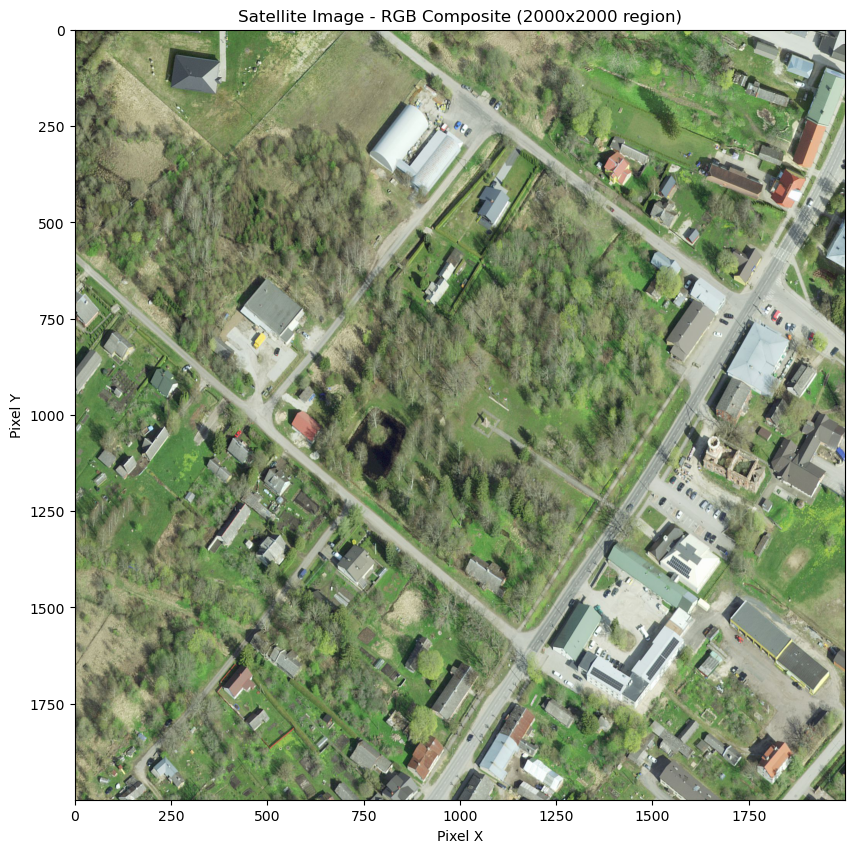

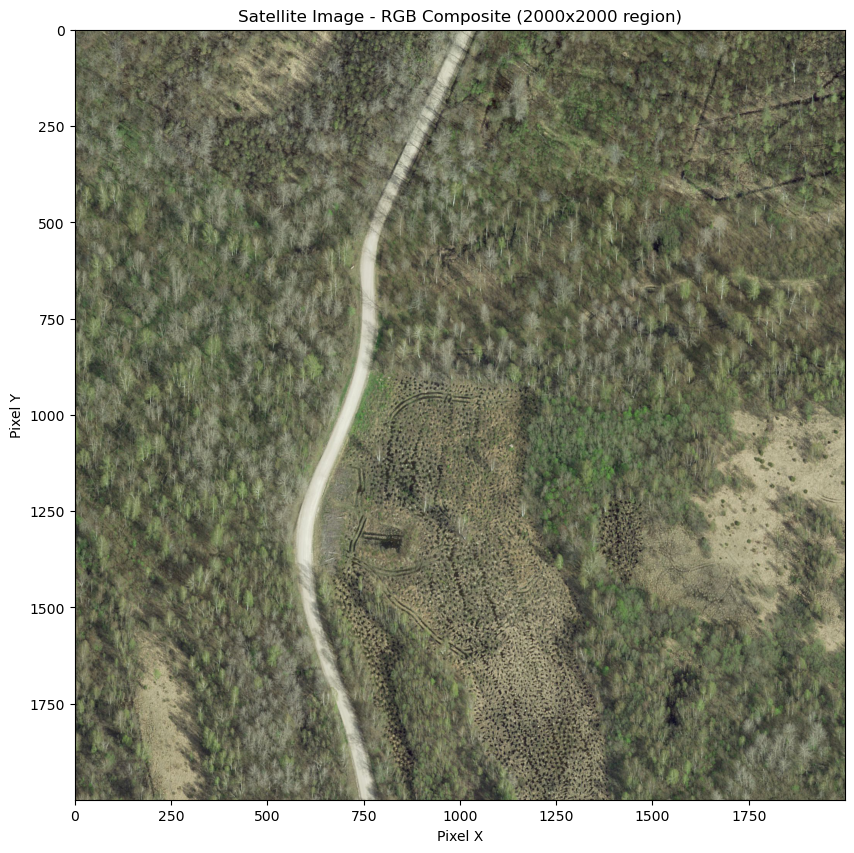

In [ ]:
# Inspecting a Satellite Image's tif file
with rasterio.open("../data/raw/satellite/62093.tif") as dataset:
    # Print dataset profile
    print(f"Dataset profile: {dataset.profile}")
    # Print width and height
    print(f"Width: {dataset.width}, Height: {dataset.height}")
    # Print coordinate reference system
    print(f"CRS: {dataset.crs}")
    # Print transform information. This includes pixel size and origin.
    print(f"Transform: {dataset.transform}")
    # Print bounds of the dataset
    print(f"Bounds: {dataset.bounds}")
    # Print number of bands
    print(f"Number of bands: {dataset.count}")
    # Print data types of the bands
    print(f"Data types: {dataset.dtypes}")
    # Print driver information
    print(f"Driver: {dataset.driver}")
    # Print no data value
    print(f"No data value: {dataset.nodata}")
    # Print metadata
    print(f"Metadata: {dataset.meta}")

    # Plot the first three bands as an RGB image
    # Very expensive in terms of memory for large images
    # band1 = dataset.read(1)
    # band2 = dataset.read(2)
    # band3 = dataset.read(3)
    # rgb_image = np.dstack((band1, band2, band3))
    # plt.figure(figsize=(10, 10))
    # plt.imshow(rgb_image)
    # plt.title('Satellite Image - RGB Composite')
    # plt.xlabel('Pixel X')
    # plt.ylabel('Pixel Y')
    # plt.show()

    # Plot a smaller region to save memory
    # Choose a 2000x2000 pixel window from the bottom-left corner
    band1 = dataset.read(
        1, window=rasterio.windows.Window(0, dataset.height - 2000, 2000, 2000)
    )
    band2 = dataset.read(
        2, window=rasterio.windows.Window(0, dataset.height - 2000, 2000, 2000)
    )
    band3 = dataset.read(
        3, window=rasterio.windows.Window(0, dataset.height - 2000, 2000, 2000)
    )
    rgb_image = np.dstack((band1, band2, band3))
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_image)
    plt.title("Satellite Image - RGB Composite (2000x2000 region)")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.show()

    # Choose a 2000x2000 pixel window from the top-left corner
    band1 = dataset.read(1, window=rasterio.windows.Window(0, 0, 2000, 2000))
    band2 = dataset.read(2, window=rasterio.windows.Window(0, 0, 2000, 2000))
    band3 = dataset.read(3, window=rasterio.windows.Window(0, 0, 2000, 2000))
    rgb_image = np.dstack((band1, band2, band3))
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_image)
    plt.title("Satellite Image - RGB Composite (2000x2000 region)")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.show()

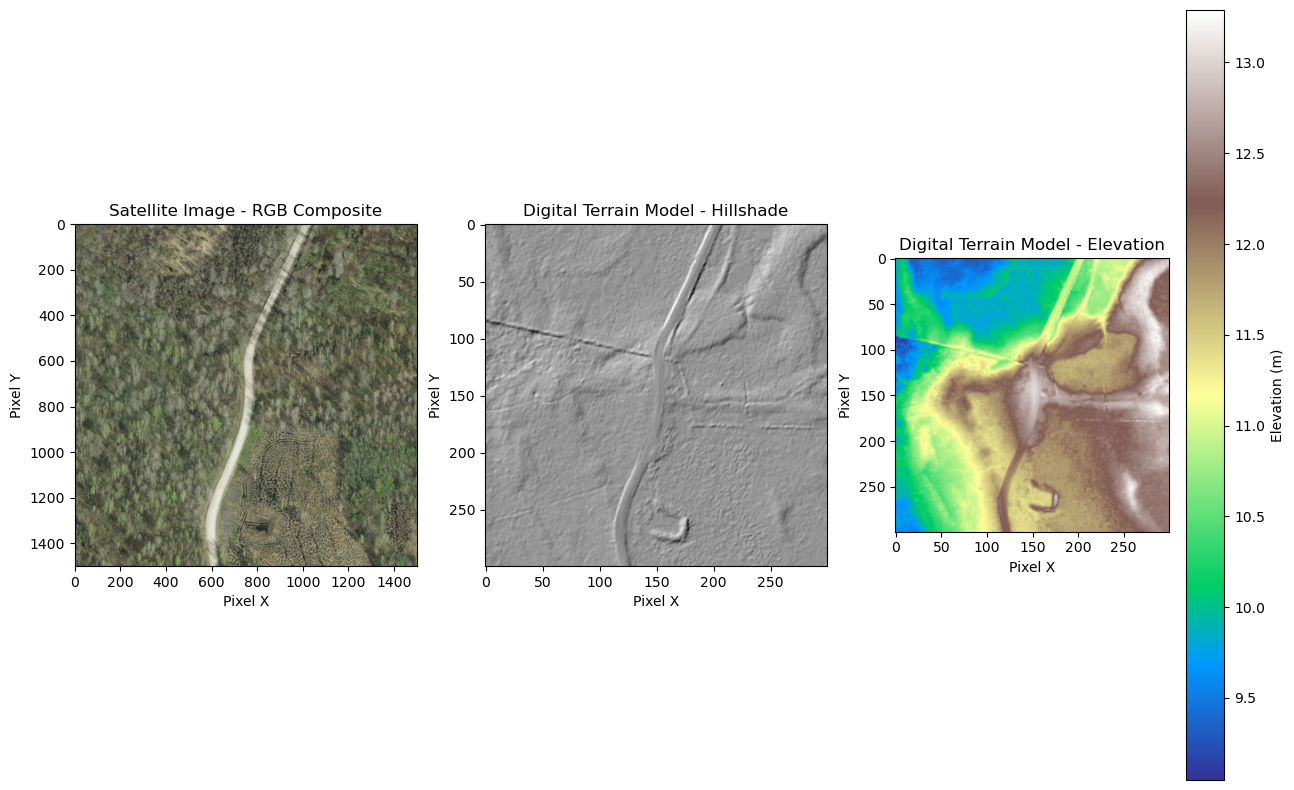

In [59]:
# Show a satellite image RGB composite and DTM visualization (hillshade and elevation) side by side
with (
    rasterio.open("../data/raw/satellite/62093.tif") as sat_dataset,
    rasterio.open("../data/raw/dtm/62093_dtm_1m.tif") as dtm_dataset,
):
    # Scale factor so that both datasets cover the same area
    scale_factor = sat_dataset.width // dtm_dataset.width
    dat_window_size = 300
    sat_window_size = dat_window_size * scale_factor
    # Read a 1000x1000 pixel window from both datasets
    sat_band1 = sat_dataset.read(
        1, window=rasterio.windows.Window(0, 0, sat_window_size, sat_window_size)
    )
    sat_band2 = sat_dataset.read(
        2, window=rasterio.windows.Window(0, 0, sat_window_size, sat_window_size)
    )
    sat_band3 = sat_dataset.read(
        3, window=rasterio.windows.Window(0, 0, sat_window_size, sat_window_size)
    )
    dtm_band1 = dtm_dataset.read(
        1, window=rasterio.windows.Window(0, 0, dat_window_size, dat_window_size)
    )

    # Create RGB composite for satellite image
    sat_rgb = np.dstack((sat_band1, sat_band2, sat_band3))
    # Create hillshade for DTM
    dtm_hillshade = hillshade(dtm_band1)

    # Plot side by side
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 10))
    ax1.imshow(sat_rgb)
    ax1.set_title("Satellite Image - RGB Composite")
    ax1.set_xlabel("Pixel X")
    ax1.set_ylabel("Pixel Y")
    ax2.imshow(dtm_hillshade, cmap="gray")
    ax2.set_title("Digital Terrain Model - Hillshade")
    ax2.set_xlabel("Pixel X")
    ax2.set_ylabel("Pixel Y")
    ax3.imshow(dtm_band1, cmap="terrain")
    ax3.set_title("Digital Terrain Model - Elevation")
    ax3.set_xlabel("Pixel X")
    ax3.set_ylabel("Pixel Y")
    fig.colorbar(ax3.images[0], ax=ax3, label="Elevation (m)")
    ax3.imshow(dtm_band1, cmap="terrain")
    plt.show()

In [ ]:
# Inspecting a Shapefile and map tile numbers CSV
shapefile_path = "../data/raw/inspire/PS_ProtectedSite_malestisedPolygon.shp"
gdf = gpd.read_file(shapefile_path)
map_tiles_df = pd.read_csv("../data/linnamagede_ruudunumbrid_v2.csv")

In [17]:
display(gdf.head())

,gml_id,gml_descri,gml_metada,gml_metad0,gml_origin,gml_parent,inspireid_,inspireid0,sitedesign,sitedesig0,sitedesig1,sitedesig2,sitename_g,sitename_0,siteprotec,xml_ns_uri,legalfound,legalfoun0,geometry
0,mka_11997874,Last update:2024-08-26,https://metadata.geoportaal.ee/geonetwork/srv/...,Eesti kultuurimälestiste register,http://www.opengis.net/def/crs/EPSG/0/3301,featureMember,mka_11997874,ee.mka.ps.registermuinas-malestised,https://inspire.ec.europa.eu/codelist/National...,monument,https://inspire.ec.europa.eu/codelist/Designat...,national monuments record,Kääbas,est,archaeological,http://inspire.ec.europa.eu/schemas/ps/4.0,true,true,"POLYGON ((701009.29 6415775.3, 701010.57 64157..."
1,mka_11997875,Last update:2024-08-26,https://metadata.geoportaal.ee/geonetwork/srv/...,Eesti kultuurimälestiste register,http://www.opengis.net/def/crs/EPSG/0/3301,featureMember,mka_11997875,ee.mka.ps.registermuinas-malestised,https://inspire.ec.europa.eu/codelist/National...,monument,https://inspire.ec.europa.eu/codelist/Designat...,national monuments record,Kääbas,est,archaeological,http://inspire.ec.europa.eu/schemas/ps/4.0,true,true,"POLYGON ((701019.53 6415786.11, 701021.31 6415..."
2,mka_11997876,Last update:2024-08-26,https://metadata.geoportaal.ee/geonetwork/srv/...,Eesti kultuurimälestiste register,http://www.opengis.net/def/crs/EPSG/0/3301,featureMember,mka_11997876,ee.mka.ps.registermuinas-malestised,https://inspire.ec.europa.eu/codelist/National...,monument,https://inspire.ec.europa.eu/codelist/Designat...,national monuments record,Kääbas,est,archaeological,http://inspire.ec.europa.eu/schemas/ps/4.0,true,true,"POLYGON ((701015.43 6415752.13, 700998.44 6415..."
3,mka_11997877,Last update:2024-08-26,https://metadata.geoportaal.ee/geonetwork/srv/...,Eesti kultuurimälestiste register,http://www.opengis.net/def/crs/EPSG/0/3301,featureMember,mka_11997877,ee.mka.ps.registermuinas-malestised,https://inspire.ec.europa.eu/codelist/National...,monument,https://inspire.ec.europa.eu/codelist/Designat...,national monuments record,Kääbas,est,archaeological,http://inspire.ec.europa.eu/schemas/ps/4.0,true,true,"POLYGON ((700959.86 6415755.76, 700965.12 6415..."
4,mka_11997879,Last update:2024-08-26,https://metadata.geoportaal.ee/geonetwork/srv/...,Eesti kultuurimälestiste register,http://www.opengis.net/def/crs/EPSG/0/3301,featureMember,mka_11997879,ee.mka.ps.registermuinas-malestised,https://inspire.ec.europa.eu/codelist/National...,monument,https://inspire.ec.europa.eu/codelist/Designat...,national monuments record,Kääbas,est,archaeological,http://inspire.ec.europa.eu/schemas/ps/4.0,true,true,"POLYGON ((700981.56 6415774.09, 700983.26 6415..."


In [ ]:
# Filter and display specific map tile information
display(map_tiles_df[map_tiles_df["Ruudunumber(1:10000)"] == "62093"])

,Linnamägi,Ruudunumber(1:2000),Ruudunumber(1:10000),Lisainfo,INSPIRE id,INSPIRE nimi,Muu
49,Lihnutsi kants,506492,62093,kaardil Lihuntsi kants,mka_10078393,Linnus,NaN
50,Lihula muinaslinnus,506490,62093,NaN,mka_10079379,Lihula mõisa park,NaN


In [ ]:
# Get and display the INSPIRE id for map tile number 62093
# This id can be used to link to the polygon features in the shapefile
inspire_ids_62093 = map_tiles_df.loc[
    map_tiles_df["Ruudunumber(1:10000)"] == "62093", "INSPIRE id"
].values
display(inspire_ids_62093)

array(['mka_10078393', 'mka_10079379'], dtype=object)

In [19]:
# Filter the GeoDataFrame for features matching the INSPIRE ids
filtered_gdf = gdf[gdf["inspireid_"].isin(inspire_ids_62093)]
display(filtered_gdf)

,gml_id,gml_descri,gml_metada,gml_metad0,gml_origin,gml_parent,inspireid_,inspireid0,sitedesign,sitedesig0,sitedesig1,sitedesig2,sitename_g,sitename_0,siteprotec,xml_ns_uri,legalfound,legalfoun0,geometry
1167,mka_10078393,Last update:2024-08-26,https://metadata.geoportaal.ee/geonetwork/srv/...,Eesti kultuurimälestiste register,http://www.opengis.net/def/crs/EPSG/0/3301,featureMember,mka_10078393,ee.mka.ps.registermuinas-malestised,https://inspire.ec.europa.eu/codelist/National...,monument,https://inspire.ec.europa.eu/codelist/Designat...,national monuments record,Linnus,est,archaeological,http://inspire.ec.europa.eu/schemas/ps/4.0,true,true,"POLYGON ((492724.29 6506613.7, 492745.18 65065..."
1534,mka_10079379,Last update:2024-08-26,https://metadata.geoportaal.ee/geonetwork/srv/...,Eesti kultuurimälestiste register,http://www.opengis.net/def/crs/EPSG/0/3301,featureMember,mka_10079379,ee.mka.ps.registermuinas-malestised,https://inspire.ec.europa.eu/codelist/National...,monument,https://inspire.ec.europa.eu/codelist/Designat...,national monuments record,Lihula mõisa park,est,cultural,http://inspire.ec.europa.eu/schemas/ps/4.0,true,true,"POLYGON ((490610.45 6505860.8, 490602.27 65058..."


X and Y axes are in the coordinate reference system of the shapefile.


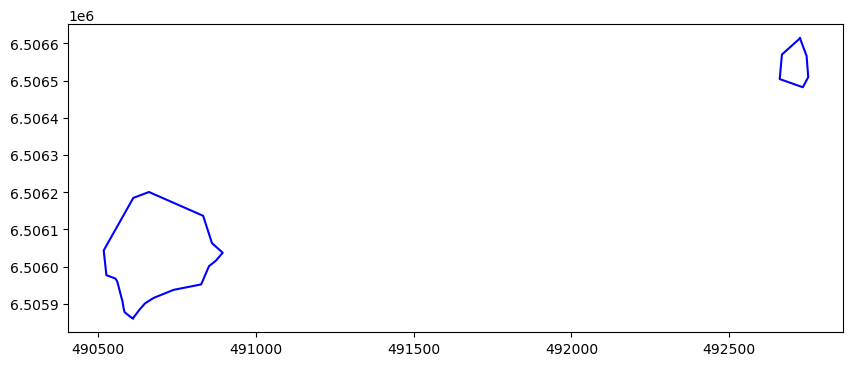

In [41]:
# Get the geometry of the filtered features
geometries = filtered_gdf["geometry"].values

# Visualize the geometries
fig, ax = plt.subplots(figsize=(10, 4))
for geom in geometries:
    if isinstance(geom, shapely.geometry.Polygon):
        x, y = geom.exterior.xy
        ax.plot(x, y, color="blue")
    elif isinstance(geom, shapely.geometry.MultiPolygon):
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.plot(x, y, color="red")
print("X and Y axes are in the coordinate reference system of the shapefile.")

In [29]:
# Get the upper left and lower right coordinates of the bounding box
# These will be used to crop satellite image for visualisation
minx, miny, maxx, maxy = filtered_gdf.total_bounds
print(f"Bounding box coordinates: ({minx}, {miny}), ({maxx}, {maxy})")

Bounding box coordinates: (490517.749999543, 6505860.799812593), (492750.3999996512, 6506613.699812616)


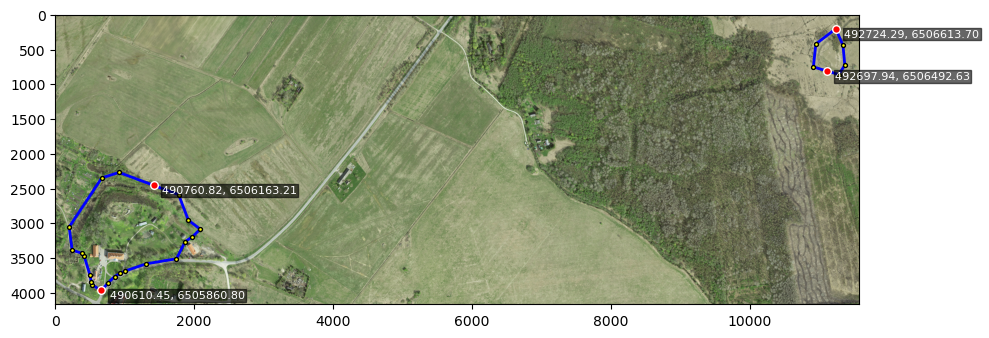

In [54]:
# Visualise the geometries over the cropped satellite image
with rasterio.open("../data/raw/satellite/62093.tif") as sat_dataset:
    # Calculate the pixel coordinates for the bounding box
    ul_row, ul_col = sat_dataset.index(minx, maxy)  # upper left
    lr_row, lr_col = sat_dataset.index(maxx, miny)  # lower right

    # increase buffer (in pixels). Increase until polygon edges are fully visible.
    buffer_pixels = 200

    # Apply buffer and ensure coordinates are within image bounds
    row_start = max(ul_row - buffer_pixels, 0)
    col_start = max(ul_col - buffer_pixels, 0)
    row_stop = min(lr_row + buffer_pixels, sat_dataset.height)
    col_stop = min(lr_col + buffer_pixels, sat_dataset.width)

    height = int(row_stop - row_start)
    width = int(col_stop - col_start)
    window = rasterio.windows.Window(col_start, row_start, width, height)

    # transform that maps pixel->world for the cropped window
    window_transform = rasterio.windows.transform(window, sat_dataset.transform)

    # read cropped RGB (adjust band indices if needed)
    band1 = sat_dataset.read(1, window=window)
    band2 = sat_dataset.read(2, window=window)
    band3 = sat_dataset.read(3, window=window)
    sat_rgb = np.dstack((band1, band2, band3))

    # Plot the cropped satellite image with geometries overlay
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(sat_rgb)
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)  # invert y so pixel rows match image origin

    inv_transform = ~window_transform  # world -> pixel for the cropped window

    # helper: sample vertices (downsampling) — keeps original vertices if few
    def sample_coords(coords, max_points=40):
        coords = list(coords)
        n = len(coords)
        if n <= max_points:
            return coords
        step = max(1, n // max_points)
        return coords[::step]

    # helper: sample evenly along the exterior (preferred to reduce overlap)
    def sample_along_exterior(line, n):
        return [
            line.interpolate(t, normalized=True)
            for t in np.linspace(0, 1, n, endpoint=False)
        ]

    poly_list = []
    for geom in geometries:
        if isinstance(geom, shapely.geometry.Polygon):
            poly_list.append(geom)
            outline_color = "blue"
        elif isinstance(geom, shapely.geometry.MultiPolygon):
            poly_list.extend(geom.geoms)
            outline_color = "red"
        else:
            continue

    for poly in poly_list:
        # Plot exterior outline
        xs, ys = poly.exterior.xy
        pxpy = [inv_transform * (x, y) for x, y in zip(xs, ys)]
        px = [p for p, _ in pxpy]
        py = [q for _, q in pxpy]
        ax.plot(px, py, color=outline_color, linewidth=2, zorder=2)

        # Plot all vertices as small unlabeled points
        exterior_coords = list(poly.exterior.coords)
        for x_w, y_w in exterior_coords:
            p_x, p_y = inv_transform * (x_w, y_w)
            ax.scatter(
                p_x, p_y, s=8, c="yellow", edgecolors="black", zorder=3, marker="o"
            )

        # Choose sampled points to label (either from vertices or evenly spaced)
        # Option A: sample vertices (less even) — uncomment if preferred
        # sampled = sample_coords(exterior_coords, max_points=10)
        # Option B: evenly spaced points along the perimeter (recommended)
        n_labels = 2
        sampled_points = sample_along_exterior(poly.exterior, n_labels)

        # Mark sampled points and annotate with coordinates
        for pt in sampled_points:
            x_w, y_w = pt.x, pt.y
            p_x, p_y = inv_transform * (x_w, y_w)
            ax.scatter(
                p_x, p_y, s=30, c="red", edgecolors="white", zorder=4, marker="o"
            )
            coord_text = f"{x_w:.2f}, {y_w:.2f}"
            ax.annotate(
                coord_text,
                xy=(p_x, p_y),
                xytext=(6, -6),
                textcoords="offset points",
                fontsize=8,
                color="white",
                bbox=dict(facecolor="black", alpha=0.6, pad=1),
                zorder=5,
            )
    plt.tight_layout()
    plt.show()

In [5]:
tile_stats_df = pd.read_csv("../tile_stats.csv")
display(tile_stats_df)

vals = tile_stats_df["positive_fraction"].fillna(0).values
print(tile_stats_df["positive_fraction"].describe())

pctl = [50, 75, 90, 95, 99, 99.5, 99.9]
print({p: np.percentile(vals, p) for p in pctl})

,image_base,x,y,rgb_tile,label_tile,dtm_tile,positive_fraction,positive_count
0,64953,0,0,64953_x00000_y00000.png,64953_x00000_y00000.png,64953_x00000_y00000.tif,0.0,0
1,64953,512,0,64953_x00512_y00000.png,64953_x00512_y00000.png,64953_x00512_y00000.tif,0.0,0
2,64953,1024,0,64953_x01024_y00000.png,64953_x01024_y00000.png,64953_x01024_y00000.tif,0.0,0
3,64953,1536,0,64953_x01536_y00000.png,64953_x01536_y00000.png,64953_x01536_y00000.tif,0.0,0
4,64953,2048,0,64953_x02048_y00000.png,64953_x02048_y00000.png,64953_x02048_y00000.tif,0.0,0
...,...,...,...,...,...,...,...,...
9553,52722,2048,4096,52722_x02048_y04096.png,52722_x02048_y04096.png,52722_x02048_y04096.tif,0.0,0
9554,52722,2560,4096,52722_x02560_y04096.png,52722_x02560_y04096.png,52722_x02560_y04096.tif,0.0,0
9555,52722,3072,4096,52722_x03072_y04096.png,52722_x03072_y04096.png,52722_x03072_y04096.tif,0.0,0
9556,52722,3584,4096,52722_x03584_y04096.png,52722_x03584_y04096.png,52722_x03584_y04096.tif,0.0,0


count    9558.000000
mean        0.002257
std         0.031960
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: positive_fraction, dtype: float64
{50: np.float64(0.0), 75: np.float64(0.0), 90: np.float64(0.0), 95: np.float64(0.0), 99: np.float64(0.041082305908203116), 99.5: np.float64(0.08531389236450229), 99.9: np.float64(0.5952281341553444)}


In [9]:
def bucket_counts(vals, small_thresh, mid_thresh):
    neg = (vals == 0).sum()
    small = ((vals > 0) & (vals <= small_thresh)).sum()
    mid = ((vals > small_thresh) & (vals <= mid_thresh)).sum()
    full = (vals > mid_thresh).sum()
    total = len(vals)
    return {
        "neg": (neg, neg / total),
        "small": (small, small / total),
        "mid": (mid, mid / total),
        "full": (full, full / total),
        "total": total,
    }


# example: current defaults used earlier
print("Chosen small_thresh=0.001, mid_thresh=0.01")
print(bucket_counts(vals, small_thresh=0.001, mid_thresh=0.01))
print("Alternative: small_thresh=0.01, mid_thresh=0.1")
print(bucket_counts(vals, small_thresh=0.01, mid_thresh=0.1))

Chosen small_thresh=0.001, mid_thresh=0.01
{'neg': (np.int64(9322), np.float64(0.9753086419753086)), 'small': (np.int64(14), np.float64(0.001464741577735928)), 'mid': (np.int64(44), np.float64(0.004603473530027202)), 'full': (np.int64(178), np.float64(0.018623142916928227)), 'total': 9558}
Alternative: small_thresh=0.01, mid_thresh=0.1
{'neg': (np.int64(9322), np.float64(0.9753086419753086)), 'small': (np.int64(58), np.float64(0.00606821510776313)), 'mid': (np.int64(134), np.float64(0.014019669386901025)), 'full': (np.int64(44), np.float64(0.004603473530027202)), 'total': 9558}


In [ ]:
df = pd.read_csv("../tile_stats.csv")
vals = df["positive_fraction"].fillna(0).values
nonzero = vals[vals > 0]

small_thresh = np.percentile(nonzero, 35)
mid_thresh = np.percentile(nonzero, 70)


def bucket_counts(vals, small_thresh, mid_thresh):
    neg = (vals == 0).sum()
    small = ((vals > 0) & (vals <= small_thresh)).sum()
    mid = ((vals > small_thresh) & (vals <= mid_thresh)).sum()
    full = (vals > mid_thresh).sum()
    total = len(vals)
    return neg, small, mid, full, total


print("small_thresh, mid_thresh:", small_thresh, mid_thresh)
print(bucket_counts(vals, small_thresh, mid_thresh))

small_thresh, mid_thresh: 0.0164699554443359 0.056335449218749944
(np.int64(9322), np.int64(83), np.int64(82), np.int64(71), 9558)
